In [1]:
import laspy
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

In [4]:
laz_path = "../data/tuile_1.laz"

las = laspy.read(laz_path)

print('Nombre de points : ', len(las.points))
print('Version : ', las.header.version)
print('Format des points : ', las.header.point_format)

crs = las.header.parse_crs()
print('CRS : ', crs.to_epsg())

Nombre de points :  18330487
Version :  1.4
Format des points :  <PointFormat(6, 0 bytes of extra dims)>
CRS :  2154


In [22]:
x = las.x
y = las.y
z = las.z

print('Xmin : ', x.min(), ' Xmax : ', x.max())
print('Ymin : ', y.min(), ' Ymax : ', y.max())
print('Zmin : ', z.min(), ' Zmax : ', z.max(), "Différence d'altitude : ", z.max() - z.min())

Xmin :  628000.0  Xmax :  628999.99
Ymin :  6881000.0  Ymax :  6881999.99
Zmin :  54.11  Zmax :  135.04 Différence d'altitude :  80.92999999999999


In [24]:
nb_points = len(las.points)
surface_xy = (x.max() - x.min()) * (y.max() - y.min())
densite = nb_points / surface_xy

print('Densité moyenne : ', densite, "points / m²")

Densité moyenne :  18.330853615235295 points / m²


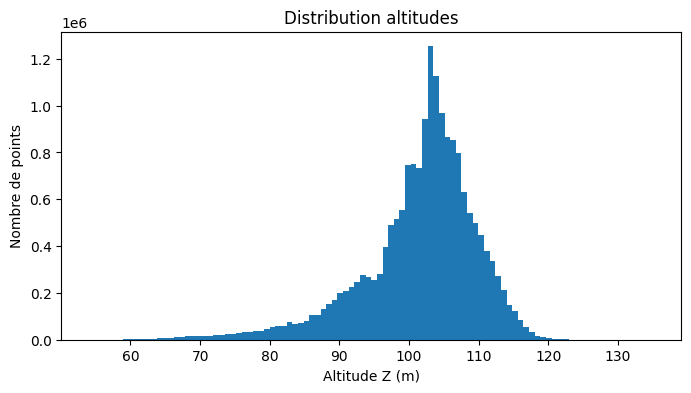

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(z, bins=100)
plt.xlabel("Altitude Z (m)")
plt.ylabel("Nombre de points")
plt.title("Distribution des altitudes")
plt.show()

In [20]:
classes = np.array(las.classification)
unique_classes, count = np.unique(classes, return_counts=True)

for c, n in zip(unique_classes, count):
    print("Classe : ", c, n, "Points")

print('(Rappel) Nombre de points total : ', las.header.point_count)

Classe :  1 836293 Points
Classe :  2 8581607 Points
Classe :  3 195901 Points
Classe :  4 463438 Points
Classe :  5 4834421 Points
Classe :  6 3416815 Points
Classe :  67 2012 Points
(Rappel) Nombre de points total :  18330487
